# ISMN Soil Moisture Data Preparation

## Objective
Prepare ISMN (International Soil Moisture Network) datasets for soil moisture prediction modeling:
- **Goal**: Predict surface and deep zone soil moisture at multiple time horizons (0h, 24h, 72h, 168h)
- **Input**: Geocoordinates to identify the area
- **Output**: Clean train/test CSV files with no data leakage

## Datasets
1. **F2PyW dataset**: Contains AMMA-CATCH and TAHMO networks (West Africa focus)
2. **gdf6E dataset**: Contains TAHMO network only (East Africa focus)

## Workflow
1. Data Loading & Understanding
2. Exploratory Data Analysis (EDA)
3. Data Quality Assessment
4. Data Cleaning & Preprocessing
5. Train/Test Split Strategy
6. Export Prepared Datasets

In [1]:
# Core imports
import sys
from pathlib import Path
from datetime import datetime, date, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    sys.path.insert(0, str(project_root / 'src'))

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Python: 3.13.11 (main, Dec  8 2025, 11:43:54) [GCC 15.2.0]
Pandas: 3.0.0
NumPy: 2.4.1


---
## 1. Dataset Structure Overview

First, let's understand what's in each dataset directory.

In [2]:
# Define dataset paths
DATA_DIR = Path('../data/ismn')

# Dataset 1: F2PyW (AMMA-CATCH + TAHMO)
DATASET_F2PYW = DATA_DIR / 'Data_separate_files_header_20170105_20250105_12892_F2PyW_20260105'

# Dataset 2: gdf6E (TAHMO only)
DATASET_GDF6E = DATA_DIR / 'Data_separate_files_header_20170105_20250105_12892_gdf6E_20260105'

print("Dataset 1 (F2PyW) exists:", DATASET_F2PYW.exists())
print("Dataset 2 (gdf6E) exists:", DATASET_GDF6E.exists())

# List networks in each dataset
print("\n=== Dataset 1 (F2PyW) Networks ===")
for item in DATASET_F2PYW.iterdir():
    if item.is_dir():
        print(f"  📁 {item.name}")

print("\n=== Dataset 2 (gdf6E) Networks ===")
for item in DATASET_GDF6E.iterdir():
    if item.is_dir():
        print(f"  📁 {item.name}")

Dataset 1 (F2PyW) exists: True
Dataset 2 (gdf6E) exists: True

=== Dataset 1 (F2PyW) Networks ===
  📁 TAHMO
  📁 AMMA-CATCH

=== Dataset 2 (gdf6E) Networks ===
  📁 TAHMO


In [3]:
def count_stations_and_files(dataset_path):
    """Count stations and files in a dataset."""
    stats = {}
    for network_dir in dataset_path.iterdir():
        if network_dir.is_dir():
            network_name = network_dir.name
            stations = [s for s in network_dir.iterdir() if s.is_dir()]
            sm_files = list(network_dir.glob('**/*_sm_*.stm'))
            stats[network_name] = {
                'n_stations': len(stations),
                'n_sm_files': len(sm_files),
                'stations': [s.name for s in stations]
            }
    return stats

print("=== Dataset 1 (F2PyW) Statistics ===")
f2pyw_stats = count_stations_and_files(DATASET_F2PYW)
for network, info in f2pyw_stats.items():
    print(f"\n{network}:")
    print(f"  Stations: {info['n_stations']}")
    print(f"  SM files: {info['n_sm_files']}")

print("\n" + "="*50)
print("=== Dataset 2 (gdf6E) Statistics ===")
gdf6e_stats = count_stations_and_files(DATASET_GDF6E)
for network, info in gdf6e_stats.items():
    print(f"\n{network}:")
    print(f"  Stations: {info['n_stations']}")
    print(f"  SM files: {info['n_sm_files']}")

=== Dataset 1 (F2PyW) Statistics ===

TAHMO:
  Stations: 23
  SM files: 29

AMMA-CATCH:
  Stations: 6
  SM files: 23

=== Dataset 2 (gdf6E) Statistics ===

TAHMO:
  Stations: 46
  SM files: 47


---
## 2. Load Data Using Existing ISMN Loader

The existing codebase has an `ISMNStationLoader` that:
- Parses .stm files for soil moisture timeseries
- Reads static_variables.csv for soil properties
- Filters quality flags (keeps G=good, M=missing but usable)
- Aggregates to daily values

**Decision**: The existing loader is well-designed and handles the core parsing. We'll use it and add additional preprocessing.

In [4]:
from smps.data.sources.ismn_loader import ISMNStationLoader, ISMNStationData

def load_dataset_stations(dataset_path):
    """Load all stations from an ISMN dataset."""
    loader = ISMNStationLoader(dataset_path)
    all_stations = {}

    networks = loader.list_networks(dataset_path)
    print(f"Found networks: {networks}")

    for network in networks:
        print(f"\nLoading network: {network}")
        try:
            stations = loader.load_network(
                network,
                dataset_path=dataset_path,
                filter_quality=True,
                aggregate_daily=True
            )
            all_stations.update(stations)
            print(f"  Loaded {len(stations)} stations")
        except Exception as e:
            print(f"  Error loading {network}: {e}")

    return all_stations

print("Loading Dataset 1 (F2PyW)...")
f2pyw_stations = load_dataset_stations(DATASET_F2PYW)

print("\n" + "="*60)
print("Loading Dataset 2 (gdf6E)...")
gdf6e_stations = load_dataset_stations(DATASET_GDF6E)

Loading Dataset 1 (F2PyW)...
Found networks: ['AMMA-CATCH', 'TAHMO']

Loading network: AMMA-CATCH
  Loaded 6 stations

Loading network: TAHMO
  Loaded 23 stations

Loading Dataset 2 (gdf6E)...
Found networks: ['TAHMO']

Loading network: TAHMO
  Loaded 46 stations


In [5]:
def summarize_stations(stations, dataset_name):
    """Create summary DataFrame of all stations."""
    rows = []
    for station_id, station in stations.items():
        if station.daily_data is None or len(station.daily_data) == 0:
            continue

        for depth in station.available_depths_cm:
            depth_data = station.daily_data[station.daily_data['depth_cm'] == depth]
            if len(depth_data) == 0:
                continue

            sm_col = 'soil_moisture_mean'
            valid_data = depth_data[sm_col].dropna()

            rows.append({
                'dataset': dataset_name,
                'network': station.network,
                'station': station.station,
                'station_id': station_id,
                'latitude': station.latitude,
                'longitude': station.longitude,
                'elevation_m': station.elevation,
                'depth_cm': depth,
                'start_date': depth_data['date'].min(),
                'end_date': depth_data['date'].max(),
                'n_days': len(depth_data),
                'n_valid': len(valid_data),
                'valid_pct': 100 * len(valid_data) / max(1, len(depth_data)),
                'sm_min': valid_data.min() if len(valid_data) > 0 else np.nan,
                'sm_max': valid_data.max() if len(valid_data) > 0 else np.nan,
                'sm_mean': valid_data.mean() if len(valid_data) > 0 else np.nan,
                'sm_std': valid_data.std() if len(valid_data) > 0 else np.nan,
                'land_cover': station.land_cover,
                'climate': station.climate_classification
            })

    return pd.DataFrame(rows)

# Create summaries for both datasets
summary_f2pyw = summarize_stations(f2pyw_stations, 'F2PyW')
summary_gdf6e = summarize_stations(gdf6e_stations, 'gdf6E')

print(f"F2PyW: {len(summary_f2pyw)} sensor-depth combinations")
print(f"gdf6E: {len(summary_gdf6e)} sensor-depth combinations")

# Combine for overall view
summary_all = pd.concat([summary_f2pyw, summary_gdf6e], ignore_index=True)
print(f"\nTotal: {len(summary_all)} sensor-depth combinations")
print(f"Unique stations: {summary_all['station_id'].nunique()}")

F2PyW: 52 sensor-depth combinations
gdf6E: 46 sensor-depth combinations

Total: 98 sensor-depth combinations
Unique stations: 75


---
## 3. Exploratory Data Analysis

In [6]:
# Overall statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

summary_all.info()
print("\n" + "="*60)
display(summary_all.describe())

DATASET OVERVIEW
<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype        
---  ------       --------------  -----        
 0   dataset      98 non-null     str          
 1   network      98 non-null     str          
 2   station      98 non-null     str          
 3   station_id   98 non-null     str          
 4   latitude     98 non-null     float64      
 5   longitude    98 non-null     float64      
 6   elevation_m  98 non-null     float64      
 7   depth_cm     98 non-null     float64      
 8   start_date   98 non-null     datetime64[s]
 9   end_date     98 non-null     datetime64[s]
 10  n_days       98 non-null     int64        
 11  n_valid      98 non-null     int64        
 12  valid_pct    98 non-null     float64      
 13  sm_min       98 non-null     float64      
 14  sm_max       98 non-null     float64      
 15  sm_mean      98 non-null     float64      
 16  sm_std       98 non-nu

,latitude,longitude,elevation_m,depth_cm,start_date,end_date,n_days,n_valid,valid_pct,sm_min,sm_max,sm_mean,sm_std
count,98.000000,98.000000,98.000000,98.000000,98,98,98.000000,98.000000,98.0,98.000000,98.000000,98.000000,98.000000
mean,4.606067,16.144701,879.843163,27.704082,2018-12-09 19:20:48,2021-06-04 13:42:51,824.112245,824.112245,100.0,0.111379,0.310275,0.195171,0.051663
min,-4.406240,-3.097250,14.000000,10.000000,2017-01-05 00:00:00,2017-05-19 00:00:00,135.000000,135.000000,100.0,0.006667,0.033708,0.028751,0.000356
25%,-0.858433,-0.093217,235.000000,10.000000,2017-02-21 00:00:00,2021-01-19 06:00:00,719.000000,719.000000,100.0,0.054470,0.277062,0.130548,0.038381
50%,6.230250,2.695600,427.500000,20.000000,2019-08-07 00:00:00,2022-07-06 00:00:00,900.500000,900.500000,100.0,0.086458,0.317729,0.187319,0.053237
75%,9.789860,34.577905,1607.250000,25.000000,2019-12-08 00:00:00,2022-07-07 00:00:00,993.750000,993.750000,100.0,0.165756,0.382914,0.268884,0.065206
max,13.645600,40.029840,2488.000000,200.000000,2020-03-27 00:00:00,2022-07-07 00:00:00,1647.000000,1647.000000,100.0,0.339350,0.457250,0.404914,0.095568
std,5.654803,17.085368,726.939961,30.061521,NaN,NaN,293.609422,293.609422,0.0,0.076659,0.102512,0.094778,0.021893


In [7]:
# Summary by dataset and network
print("=" * 60)
print("SUMMARY BY DATASET AND NETWORK")
print("=" * 60)

network_summary = summary_all.groupby(['dataset', 'network']).agg({
    'station_id': 'nunique',
    'depth_cm': lambda x: sorted(x.unique().tolist()),
    'n_days': 'sum',
    'valid_pct': 'mean',
    'sm_mean': 'mean',
    'latitude': ['min', 'max'],
    'longitude': ['min', 'max']
}).round(2)

network_summary.columns = ['_'.join(col).strip('_') for col in network_summary.columns.values]
display(network_summary)

SUMMARY BY DATASET AND NETWORK


station_id_nunique                                  depth_cm_<lambda>  n_days_sum  valid_pct_mean  sm_mean_mean  latitude_min  latitude_max  longitude_min  longitude_max
dataset network                                                                                                                                                                              
F2PyW   AMMA-CATCH                   6  [10.0, 20.0, 25.0, 40.0, 55.00000000000001, 60...       10223           100.0          0.15          9.74         13.65           1.61           2.70
        TAHMO                       23                           [10.0, 20.0, 30.0, 60.0]       25870           100.0          0.15          6.23         11.07          -3.10           5.24
gdf6E   TAHMO                       46                          [10.0, 20.0, 30.0, 200.0]       44670           100.0          0.24         -4.41          0.70          28.90          40.03

SENSOR DEPTH DISTRIBUTION


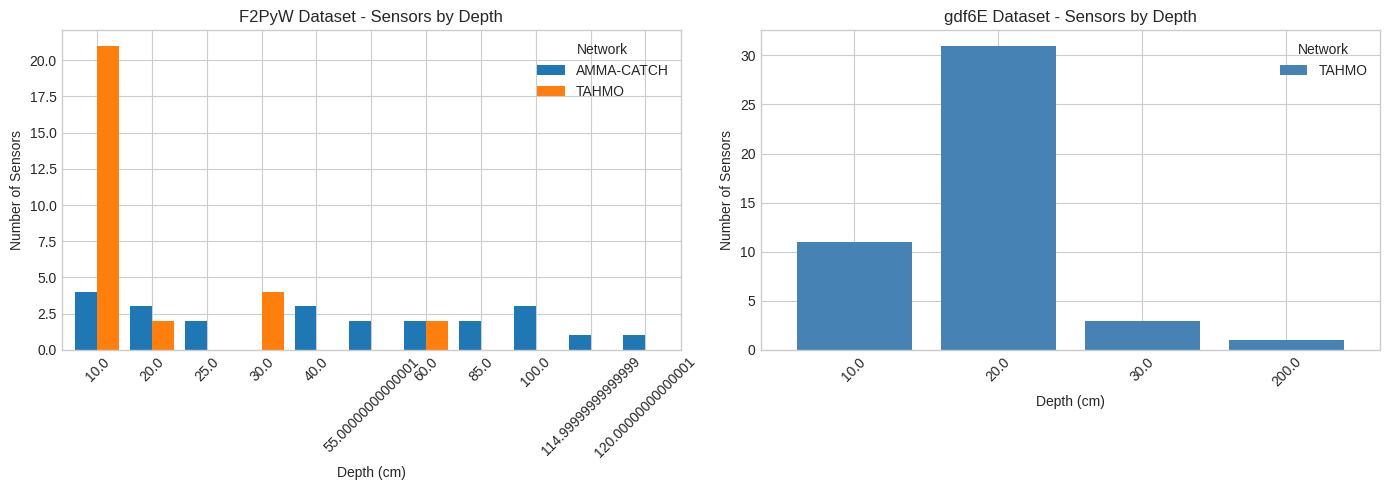


F2PyW unique depths (cm): [np.float64(10.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(40.0), np.float64(55.00000000000001), np.float64(60.0), np.float64(85.0), np.float64(100.0), np.float64(114.99999999999999), np.float64(120.00000000000001)]
gdf6E unique depths (cm): [np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(200.0)]


In [8]:
# Depth distribution
print("=" * 60)
print("SENSOR DEPTH DISTRIBUTION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F2PyW depths
ax = axes[0]
depth_counts_f2pyw = summary_f2pyw.groupby(['network', 'depth_cm']).size().unstack(fill_value=0)
depth_counts_f2pyw.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('F2PyW Dataset - Sensors by Depth', fontsize=12)
ax.set_xlabel('Depth (cm)')
ax.set_ylabel('Number of Sensors')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Network')

# gdf6E depths
ax = axes[1]
depth_counts_gdf6e = summary_gdf6e.groupby(['network', 'depth_cm']).size().unstack(fill_value=0)
depth_counts_gdf6e.T.plot(kind='bar', ax=ax, width=0.8, color='steelblue')
ax.set_title('gdf6E Dataset - Sensors by Depth', fontsize=12)
ax.set_xlabel('Depth (cm)')
ax.set_ylabel('Number of Sensors')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Network')

plt.tight_layout()
plt.show()

# Print unique depths
print(f"\nF2PyW unique depths (cm): {sorted(summary_f2pyw['depth_cm'].unique())}")
print(f"gdf6E unique depths (cm): {sorted(summary_gdf6e['depth_cm'].unique())}")

GEOGRAPHIC DISTRIBUTION


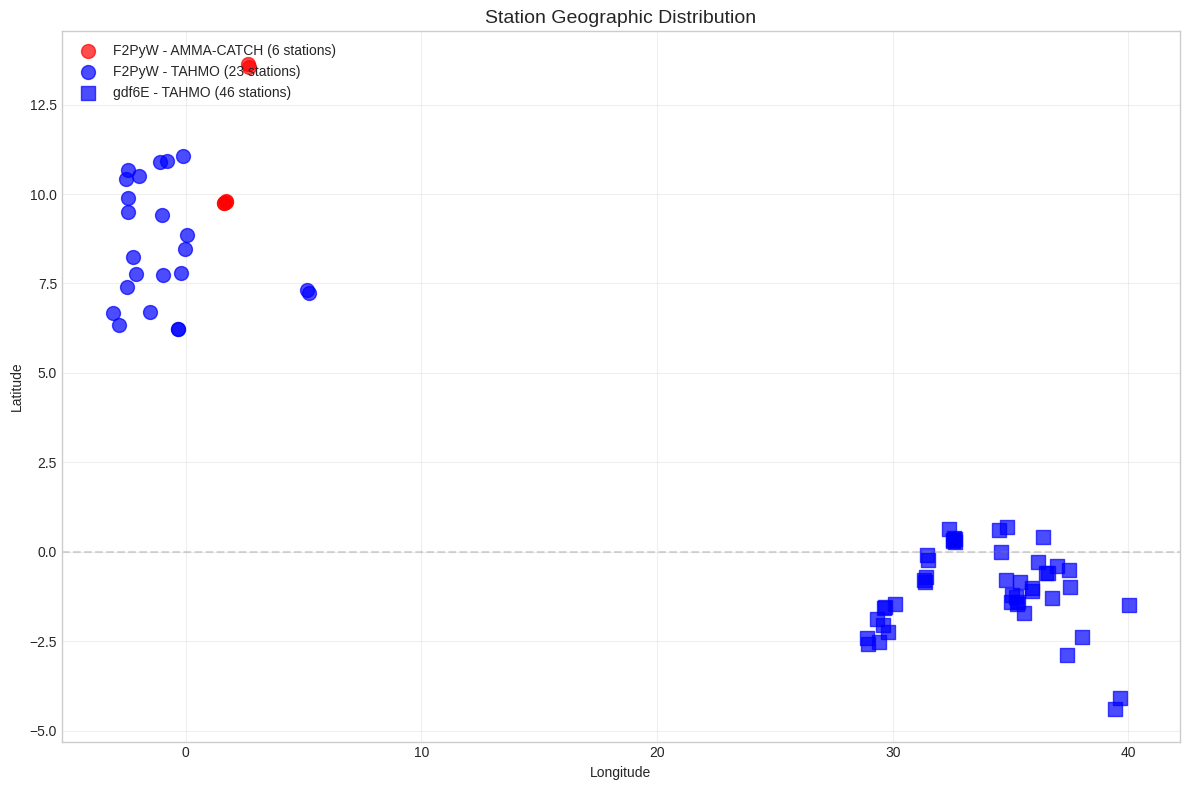


Latitude range: -4.41° to 13.65°
Longitude range: -3.10° to 40.03°


In [9]:
# Geographic distribution
print("=" * 60)
print("GEOGRAPHIC DISTRIBUTION")
print("=" * 60)

# Get unique station locations
station_locs = summary_all.drop_duplicates('station_id')[['dataset', 'network', 'station_id', 'latitude', 'longitude']]

fig, ax = plt.subplots(figsize=(12, 8))

colors = {'AMMA-CATCH': 'red', 'TAHMO': 'blue'}
markers = {'F2PyW': 'o', 'gdf6E': 's'}

for (dataset, network), group in station_locs.groupby(['dataset', 'network']):
    ax.scatter(
        group['longitude'], group['latitude'],
        c=colors.get(network, 'gray'),
        marker=markers.get(dataset, 'x'),
        s=100, alpha=0.7,
        label=f"{dataset} - {network} ({len(group)} stations)"
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Station Geographic Distribution', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Add Africa outline hint
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3, label='Equator')

plt.tight_layout()
plt.show()

print(f"\nLatitude range: {station_locs['latitude'].min():.2f}° to {station_locs['latitude'].max():.2f}°")
print(f"Longitude range: {station_locs['longitude'].min():.2f}° to {station_locs['longitude'].max():.2f}°")

SOIL MOISTURE VALUE DISTRIBUTION


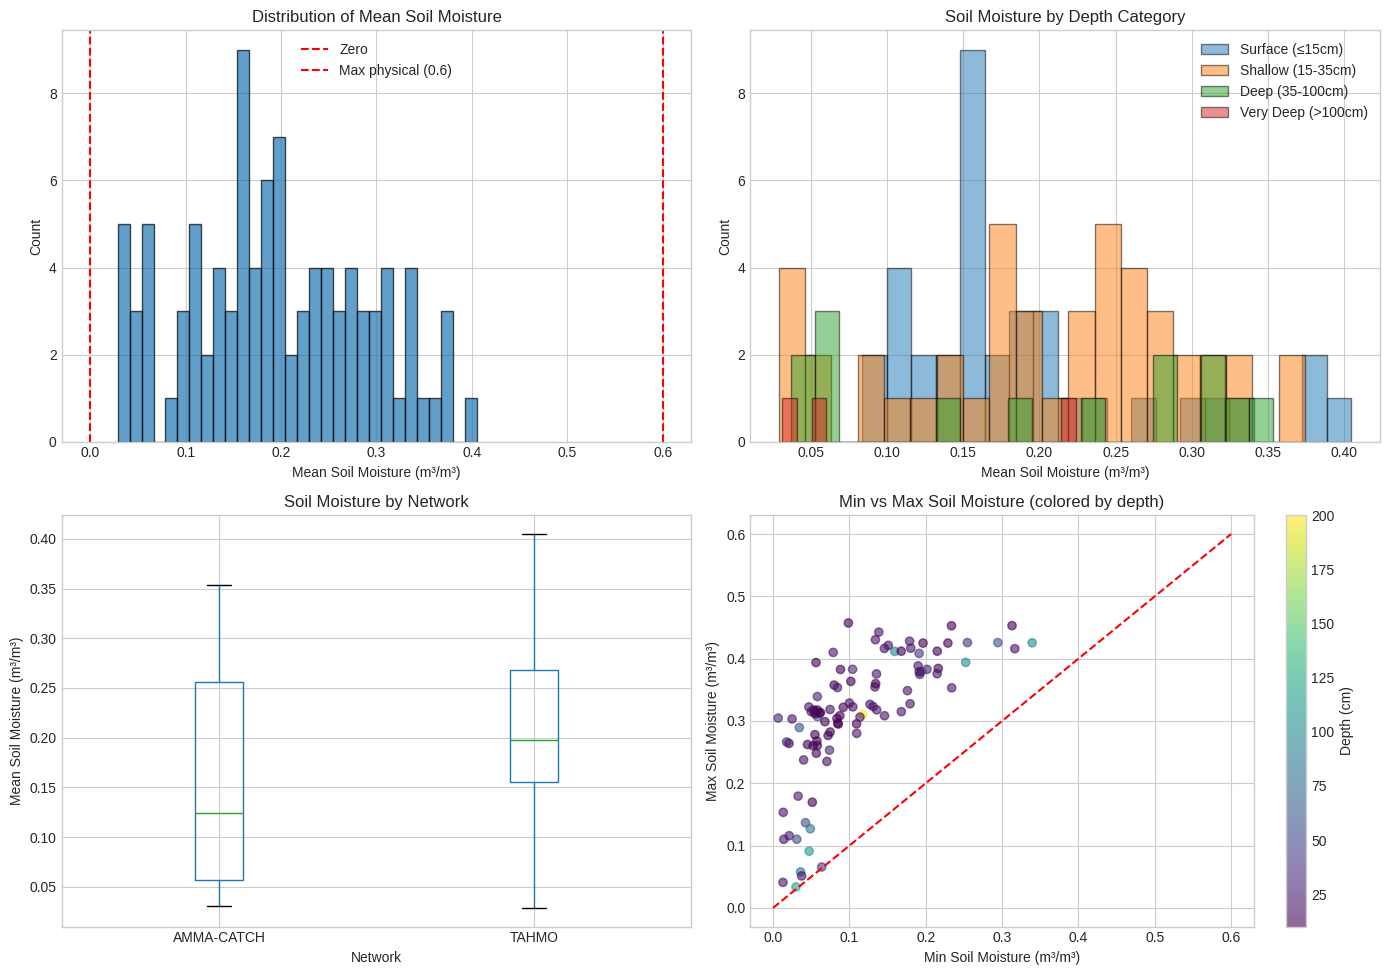

In [10]:
# Soil moisture distribution
print("=" * 60)
print("SOIL MOISTURE VALUE DISTRIBUTION")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall distribution
ax = axes[0, 0]
summary_all['sm_mean'].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', label='Zero')
ax.axvline(x=0.6, color='red', linestyle='--', label='Max physical (0.6)')
ax.set_xlabel('Mean Soil Moisture (m³/m³)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Mean Soil Moisture')
ax.legend()

# By depth
ax = axes[0, 1]
depth_bins = [0, 15, 35, 100, 200]
depth_labels = ['Surface (≤15cm)', 'Shallow (15-35cm)', 'Deep (35-100cm)', 'Very Deep (>100cm)']
summary_all['depth_category'] = pd.cut(summary_all['depth_cm'], bins=depth_bins, labels=depth_labels[:len(depth_bins)-1])

for cat in depth_labels[:len(depth_bins)-1]:
    data = summary_all[summary_all['depth_category'] == cat]['sm_mean']
    if len(data) > 0:
        ax.hist(data, bins=20, alpha=0.5, label=cat, edgecolor='black')

ax.set_xlabel('Mean Soil Moisture (m³/m³)')
ax.set_ylabel('Count')
ax.set_title('Soil Moisture by Depth Category')
ax.legend()

# Boxplot by network
ax = axes[1, 0]
summary_all.boxplot(column='sm_mean', by='network', ax=ax)
ax.set_xlabel('Network')
ax.set_ylabel('Mean Soil Moisture (m³/m³)')
ax.set_title('Soil Moisture by Network')
plt.suptitle('')

# Min/Max range
ax = axes[1, 1]
ax.scatter(summary_all['sm_min'], summary_all['sm_max'],
           c=summary_all['depth_cm'], cmap='viridis', alpha=0.6)
ax.plot([0, 0.6], [0, 0.6], 'r--', label='1:1 line')
ax.set_xlabel('Min Soil Moisture (m³/m³)')
ax.set_ylabel('Max Soil Moisture (m³/m³)')
ax.set_title('Min vs Max Soil Moisture (colored by depth)')
plt.colorbar(ax.collections[0], ax=ax, label='Depth (cm)')

plt.tight_layout()
plt.show()

TEMPORAL COVERAGE


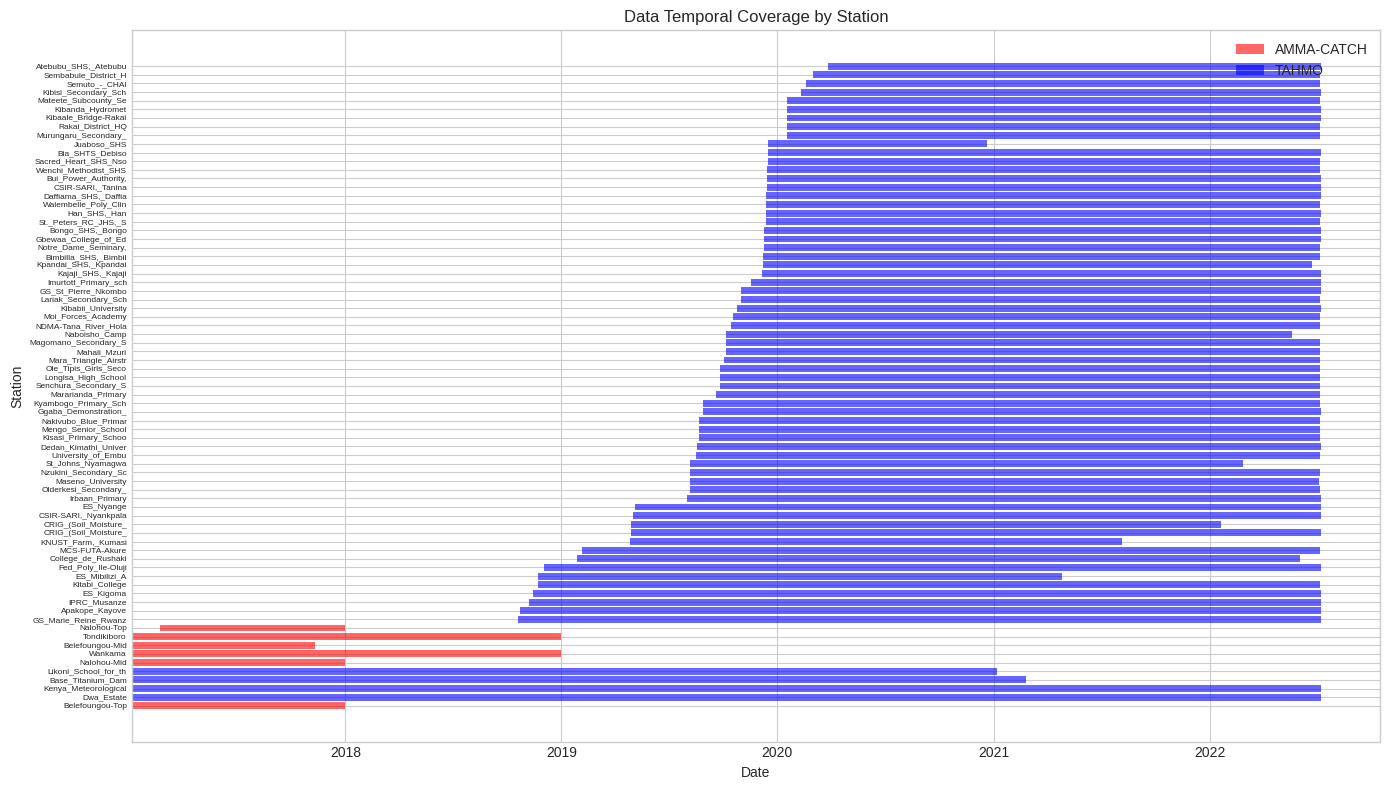


Overall date range: 2017-01-05 00:00:00 to 2022-07-07 00:00:00
Total days available: 80,763


In [11]:
# Temporal coverage
print("=" * 60)
print("TEMPORAL COVERAGE")
print("=" * 60)

fig, ax = plt.subplots(figsize=(14, 8))

# Sort stations by start date
station_order = summary_all.drop_duplicates('station_id').sort_values('start_date')['station_id'].tolist()

for i, station_id in enumerate(station_order):
    station_data = summary_all[summary_all['station_id'] == station_id].iloc[0]
    network = station_data['network']
    color = 'red' if network == 'AMMA-CATCH' else 'blue'
    ax.barh(i,
            (station_data['end_date'] - station_data['start_date']).days,
            left=station_data['start_date'],
            color=color, alpha=0.6, height=0.8)

ax.set_yticks(range(len(station_order)))
ax.set_yticklabels([s[:20] for s in station_order], fontsize=6)
ax.set_xlabel('Date')
ax.set_ylabel('Station')
ax.set_title('Data Temporal Coverage by Station')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.6, label='AMMA-CATCH'),
    Patch(facecolor='blue', alpha=0.6, label='TAHMO')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Date range summary
print(f"\nOverall date range: {summary_all['start_date'].min()} to {summary_all['end_date'].max()}")
print(f"Total days available: {summary_all['n_days'].sum():,}")

---
## 4. Data Quality Assessment

Identify quality issues following the existing codebase approach:
- Physical range violations (SM < 0 or SM > 0.6)
- Low data coverage
- Suspicious patterns (constant values, spikes)

In [12]:
# Define quality flags based on codebase approach
def assess_quality(row):
    """Assign quality flag based on various criteria."""
    issues = []

    # Check data coverage
    if row['valid_pct'] < 50:
        issues.append('LOW_COVERAGE')

    # Check for negative values
    if row['sm_min'] < 0:
        issues.append('NEGATIVE_VALUES')

    # Check for physically unrealistic high values (>0.6 m³/m³)
    if row['sm_max'] > 0.6:
        issues.append('EXCEEDS_PHYSICAL_MAX')

    # Check for very low variability (may indicate sensor issues)
    if row['sm_std'] < 0.01 and row['n_valid'] > 30:
        issues.append('LOW_VARIABILITY')

    # Check for insufficient data points
    if row['n_valid'] < 100:
        issues.append('INSUFFICIENT_DATA')

    if len(issues) == 0:
        return 'GOOD', ''
    else:
        return 'FLAGGED', ', '.join(issues)

# Apply quality assessment
summary_all[['quality_status', 'quality_issues']] = summary_all.apply(
    lambda row: pd.Series(assess_quality(row)), axis=1
)

# Quality summary
print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

quality_counts = summary_all['quality_status'].value_counts()
print(f"\nQuality Status:")
print(quality_counts)
print(f"\nGood data: {100*quality_counts.get('GOOD', 0)/len(summary_all):.1f}%")

# Issue breakdown
print("\nIssue Breakdown:")
all_issues = summary_all['quality_issues'].str.split(', ').explode()
issue_counts = all_issues[all_issues != ''].value_counts()
print(issue_counts)

DATA QUALITY ASSESSMENT

Quality Status:
quality_status
GOOD       92
FLAGGED     6
Name: count, dtype: int64

Good data: 93.9%

Issue Breakdown:
quality_issues
LOW_VARIABILITY    6
Name: count, dtype: int64


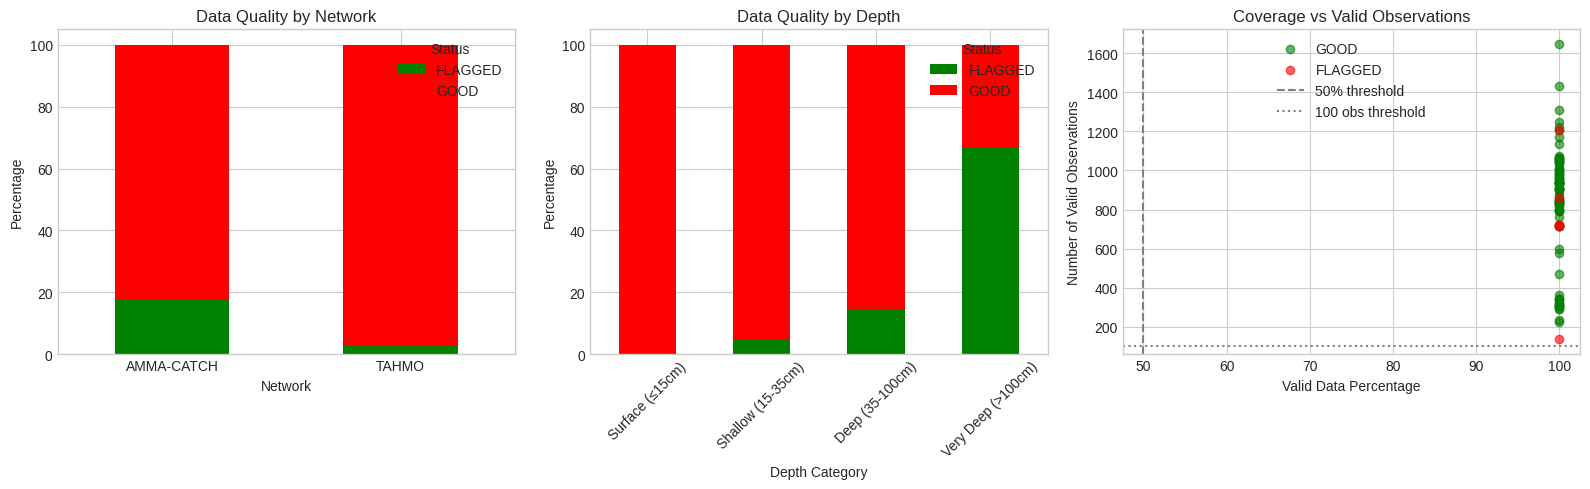

In [13]:
# Visualize quality issues
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Quality by network
ax = axes[0]
quality_by_network = pd.crosstab(summary_all['network'], summary_all['quality_status'], normalize='index') * 100
quality_by_network.plot(kind='bar', ax=ax, stacked=True, color=['green', 'red'])
ax.set_xlabel('Network')
ax.set_ylabel('Percentage')
ax.set_title('Data Quality by Network')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Status')

# Quality by depth
ax = axes[1]
quality_by_depth = pd.crosstab(summary_all['depth_category'], summary_all['quality_status'], normalize='index') * 100
quality_by_depth.plot(kind='bar', ax=ax, stacked=True, color=['green', 'red'])
ax.set_xlabel('Depth Category')
ax.set_ylabel('Percentage')
ax.set_title('Data Quality by Depth')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Status')

# Coverage vs Quality
ax = axes[2]
colors = {'GOOD': 'green', 'FLAGGED': 'red'}
for status in ['GOOD', 'FLAGGED']:
    data = summary_all[summary_all['quality_status'] == status]
    ax.scatter(data['valid_pct'], data['n_valid'], c=colors[status], alpha=0.6, label=status)

ax.set_xlabel('Valid Data Percentage')
ax.set_ylabel('Number of Valid Observations')
ax.set_title('Coverage vs Valid Observations')
ax.axvline(x=50, color='gray', linestyle='--', label='50% threshold')
ax.axhline(y=100, color='gray', linestyle=':', label='100 obs threshold')
ax.legend()

plt.tight_layout()
plt.show()

In [14]:
# Show flagged records
print("=" * 60)
print("FLAGGED DATA DETAILS")
print("=" * 60)

flagged = summary_all[summary_all['quality_status'] == 'FLAGGED'][[
    'dataset', 'network', 'station', 'depth_cm', 'n_valid', 'valid_pct',
    'sm_min', 'sm_max', 'sm_std', 'quality_issues'
]].sort_values(['network', 'station', 'depth_cm'])

print(f"\nTotal flagged sensor-depths: {len(flagged)}")
display(flagged)

FLAGGED DATA DETAILS

Total flagged sensor-depths: 6


,dataset,network,station,depth_cm,n_valid,valid_pct,sm_min,sm_max,sm_std,quality_issues
6,F2PyW,AMMA-CATCH,Nalohou-Mid,40.0,135,100.0,0.063659,0.065638,0.000356,LOW_VARIABILITY
13,F2PyW,AMMA-CATCH,Tondikiboro,85.0,722,100.0,0.036058,0.057763,0.003081,LOW_VARIABILITY
14,F2PyW,AMMA-CATCH,Tondikiboro,120.0,722,100.0,0.030017,0.033708,0.000788,LOW_VARIABILITY
10,F2PyW,AMMA-CATCH,Wankama,115.0,718,100.0,0.047275,0.091000,0.008855,LOW_VARIABILITY
87,gdf6E,TAHMO,GS_St_Pierre_Nkombo,20.0,859,100.0,0.037375,0.051292,0.003080,LOW_VARIABILITY
65,gdf6E,TAHMO,Kitabi_College,20.0,1208,100.0,0.013000,0.040958,0.005666,LOW_VARIABILITY


---
## 5. Build Combined Dataset

Combine data from both sources into a unified DataFrame:
- **Decision**: Merge datasets into one, but track source origin
- Add source dataset identifier for transparency
- Create wide-format with multi-depth soil moisture columns

In [15]:
def extract_all_observations(stations, dataset_name):
    """Extract all daily observations from stations into a single DataFrame."""
    all_obs = []

    for station_id, station in stations.items():
        if station.daily_data is None or len(station.daily_data) == 0:
            continue

        for _, row in station.daily_data.iterrows():
            obs = {
                'dataset': dataset_name,
                'network': station.network,
                'station': station.station,
                'station_id': station_id,
                'latitude': station.latitude,
                'longitude': station.longitude,
                'elevation_m': station.elevation,
                'date': row['date'],
                'depth_cm': row['depth_cm'],
                'soil_moisture': row['soil_moisture_mean'],
                'soil_moisture_min': row.get('soil_moisture_min', np.nan),
                'soil_moisture_max': row.get('soil_moisture_max', np.nan),
                'soil_moisture_std': row.get('soil_moisture_std', np.nan),
                'n_hourly_obs': row.get('n_observations', np.nan),
                'sensor_type': row.get('sensor_type', 'Unknown'),
                'land_cover': station.land_cover,
                'climate': station.climate_classification
            }

            # Add soil properties if available
            for depth_key, soil_props in station.soil_properties.items():
                # Match depth (approximately)
                depth_m = row['depth_cm'] / 100
                if soil_props.depth_from_m <= depth_m <= soil_props.depth_to_m + 0.1:
                    obs['saturation'] = soil_props.saturation
                    obs['clay_pct'] = soil_props.clay_fraction
                    obs['sand_pct'] = soil_props.sand_fraction
                    obs['silt_pct'] = soil_props.silt_fraction
                    obs['organic_carbon_pct'] = soil_props.organic_carbon
                    break

            all_obs.append(obs)

    return pd.DataFrame(all_obs)

print("Extracting all observations...")
obs_f2pyw = extract_all_observations(f2pyw_stations, 'F2PyW')
obs_gdf6e = extract_all_observations(gdf6e_stations, 'gdf6E')

print(f"F2PyW observations: {len(obs_f2pyw):,}")
print(f"gdf6E observations: {len(obs_gdf6e):,}")

# Combine
df_combined = pd.concat([obs_f2pyw, obs_gdf6e], ignore_index=True)
df_combined['date'] = pd.to_datetime(df_combined['date'])
print(f"\nCombined observations: {len(df_combined):,}")

Extracting all observations...
F2PyW observations: 36,093
gdf6E observations: 44,670

Combined observations: 80,763


In [16]:
# Combined dataset statistics
print("=" * 60)
print("COMBINED DATASET OVERVIEW")
print("=" * 60)

df_combined.info()
print("\n" + "="*60)
display(df_combined.describe())

COMBINED DATASET OVERVIEW
<class 'pandas.DataFrame'>
RangeIndex: 80763 entries, 0 to 80762
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype        
---  ------              --------------  -----        
 0   dataset             80763 non-null  str          
 1   network             80763 non-null  str          
 2   station             80763 non-null  str          
 3   station_id          80763 non-null  str          
 4   latitude            80763 non-null  float64      
 5   longitude           80763 non-null  float64      
 6   elevation_m         80763 non-null  float64      
 7   date                80763 non-null  datetime64[s]
 8   depth_cm            80763 non-null  float64      
 9   soil_moisture       80763 non-null  float64      
 10  soil_moisture_min   80763 non-null  float64      
 11  soil_moisture_max   80763 non-null  float64      
 12  soil_moisture_std   80580 non-null  float64      
 13  n_hourly_obs        80763 non-null  int64     

,latitude,longitude,elevation_m,date,depth_cm,soil_moisture,soil_moisture_min,soil_moisture_max,soil_moisture_std,n_hourly_obs,saturation,clay_pct,sand_pct,silt_pct,organic_carbon_pct
count,80763.000000,80763.000000,80763.000000,80763,80763.000000,80763.000000,80763.000000,80763.000000,80580.000000,80763.000000,75145.000000,75145.000000,75145.000000,75145.000000,75145.000000
mean,3.615942,18.884497,968.290136,2020-07-17 08:31:15,24.779850,0.197363,0.192510,0.204389,0.004080,23.333333,0.496545,28.894231,48.033336,21.790911,1.735736
min,-4.406240,-3.097250,14.000000,2017-01-05 00:00:00,10.000000,0.006667,0.000000,0.011000,0.000000,1.000000,0.390000,0.000000,0.000000,0.000000,0.200000
25%,-1.273450,-0.212640,230.000000,2019-12-20 00:00:00,10.000000,0.107729,0.102000,0.111000,0.000504,24.000000,0.410000,21.000000,36.000000,16.000000,0.650000
50%,0.376390,29.591800,791.000000,2020-10-14 00:00:00,20.000000,0.195583,0.189100,0.203000,0.001513,24.000000,0.430000,24.000000,47.000000,24.000000,0.950000
75%,9.400830,35.067180,1706.000000,2021-08-08 00:00:00,20.000000,0.279667,0.273000,0.290000,0.004027,24.000000,0.490000,39.000000,56.000000,27.000000,1.400000
max,13.645600,40.029840,2488.000000,2022-07-07 00:00:00,200.000000,0.457250,0.455000,0.483000,0.147878,24.000000,3.820000,70.000000,90.000000,68.000000,33.870000
std,5.558393,17.125183,749.297147,NaN,27.191629,0.107541,0.106085,0.111700,0.008271,2.993909,0.383440,15.502224,19.042221,10.642101,3.943765


---
## 6. Data Cleaning Pipeline

Apply cleaning steps based on codebase approach:
1. Physical range clipping (0 to 0.6 for soil moisture)
2. Remove completely invalid records
3. Flag and handle outliers
4. Handle missing values

In [17]:
# Step 1: Physical range enforcement
print("=" * 60)
print("STEP 1: Physical Range Enforcement")
print("=" * 60)

# Physical bounds for soil moisture
SM_MIN = 0.0
SM_MAX = 0.6  # Maximum reasonable saturated porosity

df_clean = df_combined.copy()

# Count violations before cleaning
neg_count = (df_clean['soil_moisture'] < SM_MIN).sum()
high_count = (df_clean['soil_moisture'] > SM_MAX).sum()
nan_count = df_clean['soil_moisture'].isna().sum()

print(f"Before cleaning:")
print(f"  Negative values: {neg_count:,} ({100*neg_count/len(df_clean):.2f}%)")
print(f"  Above max (>0.6): {high_count:,} ({100*high_count/len(df_clean):.2f}%)")
print(f"  Missing values: {nan_count:,} ({100*nan_count/len(df_clean):.2f}%)")

# Remove negative values (invalid sensor readings)
df_clean = df_clean[df_clean['soil_moisture'] >= SM_MIN]
print(f"\nAfter removing negative values: {len(df_clean):,} rows")

# Clip values above physical max
clipped_count = (df_clean['soil_moisture'] > SM_MAX).sum()
df_clean['soil_moisture'] = df_clean['soil_moisture'].clip(upper=SM_MAX)
print(f"Clipped {clipped_count:,} values to {SM_MAX}")

# Remove remaining NaN soil moisture
df_clean = df_clean.dropna(subset=['soil_moisture'])
print(f"\nAfter cleaning: {len(df_clean):,} rows remaining")

STEP 1: Physical Range Enforcement
Before cleaning:
  Negative values: 0 (0.00%)
  Above max (>0.6): 0 (0.00%)
  Missing values: 0 (0.00%)

After removing negative values: 80,763 rows
Clipped 0 values to 0.6

After cleaning: 80,763 rows remaining


In [18]:
# Step 2: Outlier detection and handling (IQR method)
print("=" * 60)
print("STEP 2: Outlier Detection")
print("=" * 60)

def detect_outliers_iqr(df, column, multiplier=1.5):
    """Detect outliers using IQR method."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR

    outliers = (df[column] < lower) | (df[column] > upper)
    return outliers, lower, upper

# Detect outliers per depth category for soil moisture
df_clean['is_outlier'] = False

for depth in df_clean['depth_cm'].unique():
    mask = df_clean['depth_cm'] == depth
    outliers, lower, upper = detect_outliers_iqr(df_clean[mask], 'soil_moisture')
    df_clean.loc[mask, 'is_outlier'] = outliers.values
    outlier_count = outliers.sum()
    if outlier_count > 0:
        print(f"Depth {depth}cm: {outlier_count} outliers (bounds: {lower:.3f} - {upper:.3f})")

total_outliers = df_clean['is_outlier'].sum()
print(f"\nTotal outliers detected: {total_outliers:,} ({100*total_outliers/len(df_clean):.2f}%)")

# Don't remove outliers yet - just flag them
print("Outliers flagged (not removed) - will be handled during feature engineering")

STEP 2: Outlier Detection
Depth 60.0cm: 15 outliers (bounds: -0.017 - 0.422)
Depth 25.0cm: 185 outliers (bounds: -0.004 - 0.083)
Depth 55.00000000000001cm: 134 outliers (bounds: 0.013 - 0.068)
Depth 85.0cm: 91 outliers (bounds: 0.018 - 0.069)
Depth 114.99999999999999cm: 103 outliers (bounds: 0.044 - 0.054)
Depth 120.00000000000001cm: 47 outliers (bounds: 0.030 - 0.032)

Total outliers detected: 575 (0.71%)
Outliers flagged (not removed) - will be handled during feature engineering


In [19]:
# Step 3: Add derived quality metrics
print("=" * 60)
print("STEP 3: Add Quality Metrics")
print("=" * 60)

# Add observation count per station-depth
obs_counts = df_clean.groupby(['station_id', 'depth_cm']).size().reset_index(name='total_obs_at_depth')
df_clean = df_clean.merge(obs_counts, on=['station_id', 'depth_cm'], how='left')

# Add year and month for temporal analysis
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day_of_year'] = df_clean['date'].dt.dayofyear

# Add data quality score (0-1)
df_clean['data_quality_score'] = (
    (~df_clean['is_outlier']).astype(float) * 0.5 +
    (df_clean['total_obs_at_depth'] > 100).astype(float) * 0.3 +
    df_clean['soil_moisture'].notna().astype(float) * 0.2
)

print(f"Quality score statistics:")
print(df_clean['data_quality_score'].describe())

STEP 3: Add Quality Metrics
Quality score statistics:
count    80763.000000
mean         0.996440
std          0.042039
min          0.500000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: data_quality_score, dtype: float64


In [20]:
# Cleaning summary
print("=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)

print(f"\nOriginal observations: {len(df_combined):,}")
print(f"After cleaning: {len(df_clean):,}")
print(f"Removed: {len(df_combined) - len(df_clean):,} ({100*(len(df_combined) - len(df_clean))/len(df_combined):.2f}%)")

print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"Unique stations: {df_clean['station_id'].nunique()}")
print(f"Unique depths: {sorted(df_clean['depth_cm'].unique())}")
print(f"Date range: {df_clean['date'].min()} to {df_clean['date'].max()}")

CLEANING SUMMARY

Original observations: 80,763
After cleaning: 80,763
Removed: 0 (0.00%)

Cleaned dataset shape: (80763, 28)
Unique stations: 75
Unique depths: [np.float64(10.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(40.0), np.float64(55.00000000000001), np.float64(60.0), np.float64(85.0), np.float64(100.0), np.float64(114.99999999999999), np.float64(120.00000000000001), np.float64(200.0)]
Date range: 2017-01-05 00:00:00 to 2022-07-07 00:00:00


---
## 7. Train/Test Split Strategy

**Critical**: Avoid data leakage!

### Strategy: Mixed Geographic Regions + Temporal Split

**Recommended Approach** (mixing West & East Africa):
1. **Mix stations from both regions** in both train and test sets - this is good because:
   - Model learns diverse climate patterns (Sahel vs. Equatorial)
   - Better generalization across different soil and vegetation types
   - Avoids regional bias in predictions

2. **Temporal split** within each region:
   - Train: Earlier time period (e.g., 2017-2021)
   - Test: Later time period (e.g., 2021-2022)
   - No future data leaks into training

3. **Spatial holdout** for generalization testing:
   - Hold out ~20% of stations from EACH region (not just one)
   - These stations are completely unseen during training
   - Tests ability to predict for new locations

### Why Mix Regions?
- Your goal is to predict soil moisture for ANY geocoordinate
- Model needs exposure to different climates during training
- Keeping regions separate would limit generalization

In [21]:
# Analyze data distribution for optimal split
print("=" * 60)
print("SPLIT ANALYSIS")
print("=" * 60)

# Actual date range
print(f"\nData date range: {df_clean['date'].min()} to {df_clean['date'].max()}")

# Distribution by year
yearly_counts = df_clean.groupby('year').size()
print(f"\nObservations by year:")
print(yearly_counts)

# Distribution by region (based on longitude)
df_clean['region'] = np.where(df_clean['longitude'] < 15, 'West Africa', 'East Africa')
region_counts = df_clean.groupby('region').agg({
    'station_id': 'nunique',
    'date': 'count'
}).rename(columns={'date': 'observations'})
print(f"\nObservations by region:")
print(region_counts)

# Find 80-20 temporal split point
cumsum = yearly_counts.cumsum()
total = cumsum.iloc[-1]
split_idx = (cumsum <= 0.8 * total).sum() - 1  # Adjust to get ~80%
split_year = yearly_counts.index[max(0, split_idx)]

print(f"\nRecommended temporal split:")
print(f"  Train: up to end of {split_year} (~80% of data)")
print(f"  Test: {split_year + 1} onwards (~20% of data)")

SPLIT ANALYSIS

Data date range: 2017-01-05 00:00:00 to 2022-07-07 00:00:00

Observations by year:
year
2017     8284
2018     3731
2019     8787
2020    25220
2021    23624
2022    11117
dtype: int64

Observations by region:
             station_id  observations
region                               
East Africa          46         44670
West Africa          29         36093

Recommended temporal split:
  Train: up to end of 2020 (~80% of data)
  Test: 2021 onwards (~20% of data)


In [22]:
# Create train/test split - MIXING STATIONS FROM BOTH REGIONS
print("=" * 60)
print("CREATING TRAIN/TEST SPLITS (Mixed Regions)")
print("=" * 60)

# Temporal split date - end of 2021 gives ~80% train, 20% test
SPLIT_DATE = pd.Timestamp('2021-12-31')

# Spatial holdout: Select ~20% of stations from EACH region
# This ensures both West and East Africa are represented in both train and test
np.random.seed(42)  # For reproducibility

# Get unique stations per region
west_africa_stations = df_clean[df_clean['region'] == 'West Africa']['station_id'].unique()
east_africa_stations = df_clean[df_clean['region'] == 'East Africa']['station_id'].unique()

# Hold out ~20% from each region
n_holdout_west = max(1, int(len(west_africa_stations) * 0.2))
n_holdout_east = max(1, int(len(east_africa_stations) * 0.2))

spatial_holdout_west = set(np.random.choice(west_africa_stations, n_holdout_west, replace=False))
spatial_holdout_east = set(np.random.choice(east_africa_stations, n_holdout_east, replace=False))
spatial_holdout_stations = spatial_holdout_west | spatial_holdout_east

print(f"Temporal split date: {SPLIT_DATE}")
print(f"\nSpatial holdout stations (for generalization testing):")
print(f"  From West Africa: {n_holdout_west} stations")
print(f"  From East Africa: {n_holdout_east} stations")
print(f"  Total holdout: {len(spatial_holdout_stations)} stations")

# Create split labels
def assign_split(row):
    """Assign train/test split with temporal and spatial considerations."""
    # Spatial holdout stations go to test only (regardless of date)
    if row['station_id'] in spatial_holdout_stations:
        return 'test_spatial'
    # Temporal split for non-holdout stations
    elif row['date'] <= SPLIT_DATE:
        return 'train'
    else:
        return 'test_temporal'

df_clean['split'] = df_clean.apply(assign_split, axis=1)

# Summary
split_summary = df_clean.groupby('split').agg({
    'date': ['min', 'max', 'count'],
    'station_id': 'nunique'
}).round(2)
split_summary.columns = ['date_min', 'date_max', 'n_observations', 'n_stations']
print("\n" + "="*60)
print("SPLIT SUMMARY")
print("="*60)
display(split_summary)

# Show regional distribution in each split
print("\n" + "="*60)
print("REGIONAL DISTRIBUTION IN EACH SPLIT")
print("="*60)
region_split = df_clean.groupby(['split', 'region']).agg({
    'station_id': 'nunique',
    'date': 'count'
}).rename(columns={'date': 'observations', 'station_id': 'n_stations'})
display(region_split)

CREATING TRAIN/TEST SPLITS (Mixed Regions)
Temporal split date: 2021-12-31 00:00:00

Spatial holdout stations (for generalization testing):
  From West Africa: 5 stations
  From East Africa: 9 stations
  Total holdout: 14 stations

SPLIT SUMMARY


,date_min,date_max,n_observations,n_stations
split,,,,
test_spatial,2017-01-05,2022-07-07,15558,14
test_temporal,2022-01-01,2022-07-07,8553,50
train,2017-01-05,2021-12-31,56652,61



REGIONAL DISTRIBUTION IN EACH SPLIT


n_stations  observations
split         region                               
test_spatial  East Africa           9          9470
              West Africa           5          6088
test_temporal East Africa          34          5765
              West Africa          16          2788
train         East Africa          37         29435
              West Africa          24         27217

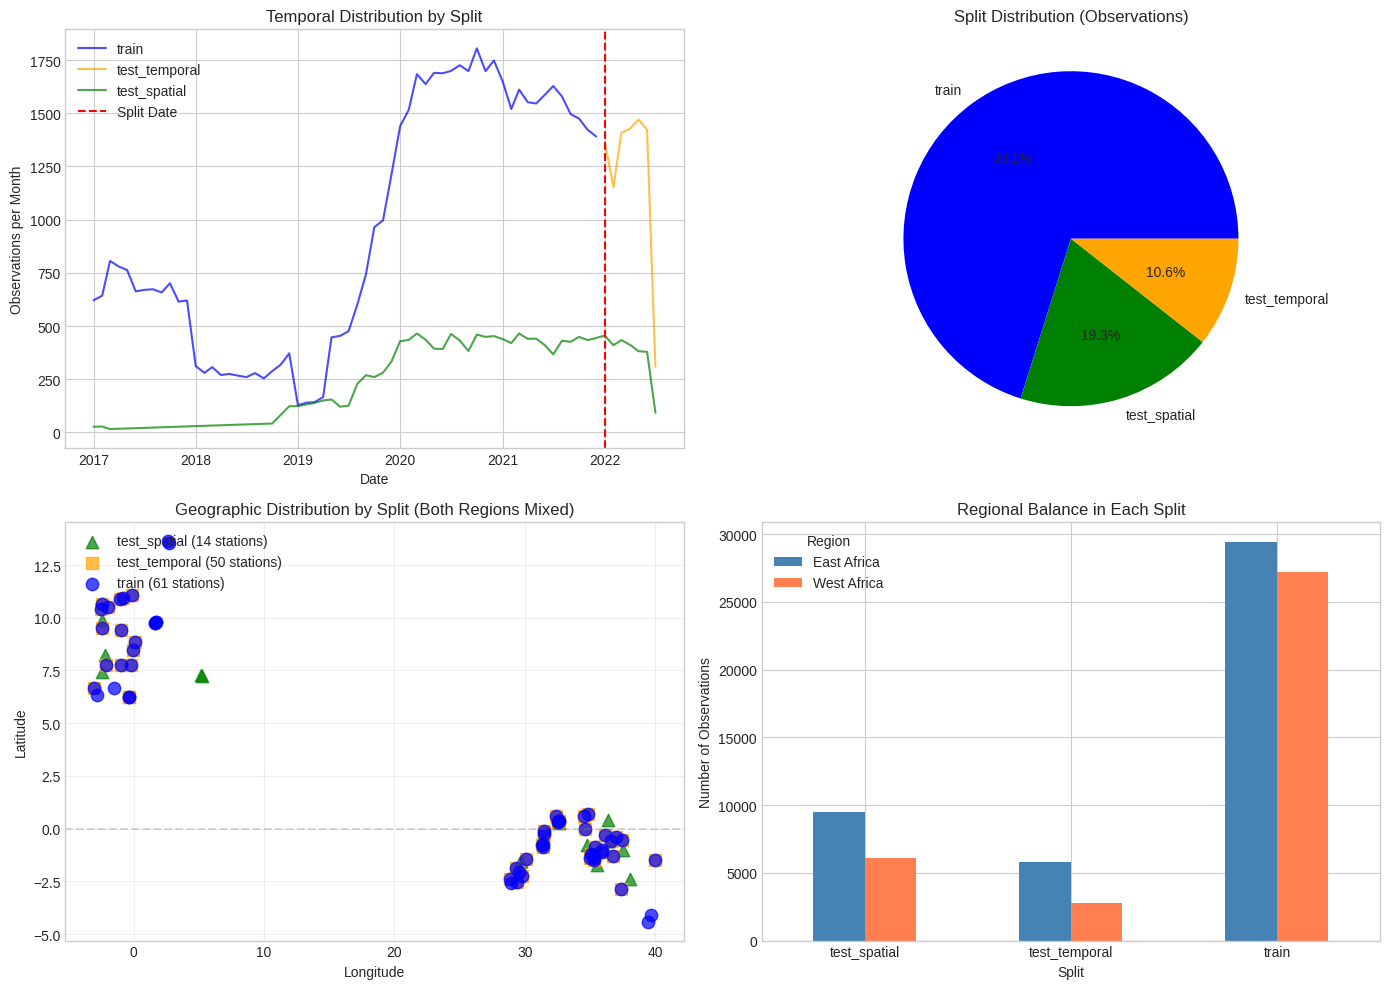


✅ Both West and East Africa stations are represented in train AND test sets
✅ Model will learn from diverse climatic conditions during training
✅ Testing includes both temporal (future prediction) and spatial (new locations) evaluation


In [23]:
# Visualize splits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Temporal distribution by split
ax = axes[0, 0]
colors = {'train': 'blue', 'test_temporal': 'orange', 'test_spatial': 'green'}
for split in ['train', 'test_temporal', 'test_spatial']:
    data = df_clean[df_clean['split'] == split]
    monthly = data.groupby(data['date'].dt.to_period('M')).size()
    monthly.index = monthly.index.to_timestamp()
    ax.plot(monthly.index, monthly.values, label=split, color=colors[split], alpha=0.7)

ax.axvline(x=SPLIT_DATE, color='red', linestyle='--', label='Split Date')
ax.set_xlabel('Date')
ax.set_ylabel('Observations per Month')
ax.set_title('Temporal Distribution by Split')
ax.legend()

# 2. Pie chart of split sizes
ax = axes[0, 1]
split_sizes = df_clean['split'].value_counts()
ax.pie(split_sizes, labels=split_sizes.index, autopct='%1.1f%%',
       colors=[colors[s] for s in split_sizes.index])
ax.set_title('Split Distribution (Observations)')

# 3. Geographic distribution by split
ax = axes[1, 0]
split_markers = {'train': 'o', 'test_temporal': 's', 'test_spatial': '^'}
for split, group in df_clean.groupby('split'):
    station_locs = group.drop_duplicates('station_id')
    ax.scatter(station_locs['longitude'], station_locs['latitude'],
               c=colors[split], marker=split_markers[split],
               s=80, alpha=0.7, label=f"{split} ({len(station_locs)} stations)")

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution by Split (Both Regions Mixed)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# 4. Regional balance in each split
ax = axes[1, 1]
region_split_counts = df_clean.groupby(['split', 'region']).size().unstack(fill_value=0)
region_split_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_xlabel('Split')
ax.set_ylabel('Number of Observations')
ax.set_title('Regional Balance in Each Split')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Region')

plt.tight_layout()
plt.show()

print("\n✅ Both West and East Africa stations are represented in train AND test sets")
print("✅ Model will learn from diverse climatic conditions during training")
print("✅ Testing includes both temporal (future prediction) and spatial (new locations) evaluation")

In [24]:
# Verify no data leakage
print("=" * 60)
print("DATA LEAKAGE VERIFICATION")
print("=" * 60)

train_data = df_clean[df_clean['split'] == 'train']
test_temporal = df_clean[df_clean['split'] == 'test_temporal']
test_spatial = df_clean[df_clean['split'] == 'test_spatial']

# Check temporal overlap
train_max_date = train_data['date'].max()
test_temporal_min_date = test_temporal['date'].min() if len(test_temporal) > 0 else None

print(f"\n1. TEMPORAL LEAKAGE CHECK")
print(f"   Train set max date: {train_max_date}")
print(f"   Test (temporal) min date: {test_temporal_min_date}")

if test_temporal_min_date and train_max_date >= test_temporal_min_date:
    print("   ❌ TEMPORAL LEAKAGE DETECTED!")
else:
    print("   ✅ No temporal leakage - test dates are strictly after train dates")

# Check spatial overlap between train and spatial holdout
print(f"\n2. SPATIAL LEAKAGE CHECK")
train_stations = set(train_data['station_id'].unique())
test_spatial_stations = set(test_spatial['station_id'].unique())

station_overlap = train_stations.intersection(test_spatial_stations)
if len(station_overlap) > 0:
    print(f"   ❌ SPATIAL LEAKAGE DETECTED! Overlapping stations: {station_overlap}")
else:
    print(f"   ✅ No spatial leakage - holdout stations completely unseen in training")

# Summary of splits
print(f"\n" + "="*60)
print("FINAL SPLIT SUMMARY")
print("="*60)
print(f"\n📊 TRAIN SET:")
print(f"   Observations: {len(train_data):,}")
print(f"   Stations: {len(train_stations)} (from both West & East Africa)")
print(f"   Date range: {train_data['date'].min()} to {train_data['date'].max()}")

print(f"\n📊 TEST SET (Temporal):")
print(f"   Observations: {len(test_temporal):,}")
print(f"   Stations: {test_temporal['station_id'].nunique()} (same stations as train, future dates)")
print(f"   Date range: {test_temporal['date'].min()} to {test_temporal['date'].max()}")
print(f"   Purpose: Test prediction on known locations, unseen time periods")

print(f"\n📊 TEST SET (Spatial):")
print(f"   Observations: {len(test_spatial):,}")
print(f"   Stations: {len(test_spatial_stations)} (completely new stations)")
print(f"   Date range: {test_spatial['date'].min()} to {test_spatial['date'].max()}")
print(f"   Purpose: Test generalization to completely unseen locations")

# List holdout station names
print(f"\n🔒 Spatial Holdout Stations:")
holdout_info = test_spatial.drop_duplicates('station_id')[['station_id', 'station', 'region']].sort_values('region')
for _, row in holdout_info.iterrows():
    print(f"   - {row['station']} ({row['region']})")

DATA LEAKAGE VERIFICATION

1. TEMPORAL LEAKAGE CHECK
   Train set max date: 2021-12-31 00:00:00
   Test (temporal) min date: 2022-01-01 00:00:00
   ✅ No temporal leakage - test dates are strictly after train dates

2. SPATIAL LEAKAGE CHECK
   ✅ No spatial leakage - holdout stations completely unseen in training

FINAL SPLIT SUMMARY

📊 TRAIN SET:
   Observations: 56,652
   Stations: 61 (from both West & East Africa)
   Date range: 2017-01-05 00:00:00 to 2021-12-31 00:00:00

📊 TEST SET (Temporal):
   Observations: 8,553
   Stations: 50 (same stations as train, future dates)
   Date range: 2022-01-01 00:00:00 to 2022-07-07 00:00:00
   Purpose: Test prediction on known locations, unseen time periods

📊 TEST SET (Spatial):
   Observations: 15,558
   Stations: 14 (completely new stations)
   Date range: 2017-01-05 00:00:00 to 2022-07-07 00:00:00
   Purpose: Test generalization to completely unseen locations

🔒 Spatial Holdout Stations:
   - St_Johns_Nyamagwa (East Africa)
   - Dwa_Estate (Ea

---
## 8. Export Prepared Datasets

Export clean train and test CSVs with clear naming.

In [25]:
# Prepare final columns for export
export_columns = [
    # Identifiers
    'dataset', 'network', 'station', 'station_id', 'region',
    # Location
    'latitude', 'longitude', 'elevation_m',
    # Time
    'date', 'year', 'month', 'day_of_year',
    # Target
    'depth_cm', 'soil_moisture', 'soil_moisture_min', 'soil_moisture_max', 'soil_moisture_std',
    # Metadata
    'sensor_type', 'land_cover', 'climate',
    # Soil properties
    'saturation', 'clay_pct', 'sand_pct', 'silt_pct', 'organic_carbon_pct',
    # Quality
    'n_hourly_obs', 'total_obs_at_depth', 'is_outlier', 'data_quality_score',
    # Split
    'split'
]

# Ensure all columns exist
for col in export_columns:
    if col not in df_clean.columns:
        df_clean[col] = np.nan

df_export = df_clean[export_columns].copy()
print(f"Export dataset shape: {df_export.shape}")
print(f"\nColumns ({len(df_export.columns)}):")
for i, col in enumerate(df_export.columns, 1):
    print(f"  {i:2d}. {col}")

Export dataset shape: (80763, 30)

Columns (30):
   1. dataset
   2. network
   3. station
   4. station_id
   5. region
   6. latitude
   7. longitude
   8. elevation_m
   9. date
  10. year
  11. month
  12. day_of_year
  13. depth_cm
  14. soil_moisture
  15. soil_moisture_min
  16. soil_moisture_max
  17. soil_moisture_std
  18. sensor_type
  19. land_cover
  20. climate
  21. saturation
  22. clay_pct
  23. sand_pct
  24. silt_pct
  25. organic_carbon_pct
  26. n_hourly_obs
  27. total_obs_at_depth
  28. is_outlier
  29. data_quality_score
  30. split


In [26]:
# Create output directory
OUTPUT_DIR = Path('../data/prepared')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Export full dataset
full_path = OUTPUT_DIR / 'ismn_soil_moisture_full.csv'
df_export.to_csv(full_path, index=False)
print(f"Exported full dataset: {full_path}")

# Export train set
train_df = df_export[df_export['split'] == 'train'].drop(columns=['split'])
train_path = OUTPUT_DIR / 'ismn_soil_moisture_train.csv'
train_df.to_csv(train_path, index=False)
print(f"Exported train set: {train_path} ({len(train_df):,} rows)")

# Export test sets
test_temporal_df = df_export[df_export['split'] == 'test_temporal'].drop(columns=['split'])
test_temporal_path = OUTPUT_DIR / 'ismn_soil_moisture_test_temporal.csv'
test_temporal_df.to_csv(test_temporal_path, index=False)
print(f"Exported test (temporal): {test_temporal_path} ({len(test_temporal_df):,} rows)")

test_spatial_df = df_export[df_export['split'] == 'test_spatial'].drop(columns=['split'])
test_spatial_path = OUTPUT_DIR / 'ismn_soil_moisture_test_spatial.csv'
test_spatial_df.to_csv(test_spatial_path, index=False)
print(f"Exported test (spatial): {test_spatial_path} ({len(test_spatial_df):,} rows)")

# Combined test set for convenience
test_all_df = df_export[df_export['split'].str.startswith('test')].copy()
test_all_df['test_type'] = test_all_df['split'].str.replace('test_', '')
test_all_df = test_all_df.drop(columns=['split'])
test_all_path = OUTPUT_DIR / 'ismn_soil_moisture_test.csv'
test_all_df.to_csv(test_all_path, index=False)
print(f"Exported combined test: {test_all_path} ({len(test_all_df):,} rows)")

Exported full dataset: ../data/prepared/ismn_soil_moisture_full.csv
Exported train set: ../data/prepared/ismn_soil_moisture_train.csv (56,652 rows)
Exported test (temporal): ../data/prepared/ismn_soil_moisture_test_temporal.csv (8,553 rows)
Exported test (spatial): ../data/prepared/ismn_soil_moisture_test_spatial.csv (15,558 rows)
Exported combined test: ../data/prepared/ismn_soil_moisture_test.csv (24,111 rows)


In [27]:
# Export metadata/summary
import json

metadata = {
    'created_at': datetime.now().isoformat(),
    'source_datasets': {
        'F2PyW': str(DATASET_F2PYW),
        'gdf6E': str(DATASET_GDF6E)
    },
    'date_range': {
        'start': str(df_clean['date'].min()),
        'end': str(df_clean['date'].max())
    },
    'split_strategy': {
        'description': 'Mixed regions (West + East Africa) with temporal split + spatial holdout',
        'temporal_split_date': str(SPLIT_DATE),
        'train_date_range': f"{train_data['date'].min()} to {train_data['date'].max()}",
        'test_temporal_date_range': f"{test_temporal['date'].min()} to {test_temporal['date'].max()}",
        'spatial_holdout_stations': sorted(list(spatial_holdout_stations)),
        'holdout_stations_west_africa': sorted(list(spatial_holdout_west)),
        'holdout_stations_east_africa': sorted(list(spatial_holdout_east))
    },
    'statistics': {
        'total_observations': len(df_export),
        'train_observations': len(train_data),
        'test_temporal_observations': len(test_temporal),
        'test_spatial_observations': len(test_spatial),
        'unique_stations': int(df_export['station_id'].nunique()),
        'train_stations': int(train_data['station_id'].nunique()),
        'test_temporal_stations': int(test_temporal['station_id'].nunique()),
        'test_spatial_stations': int(test_spatial['station_id'].nunique()),
        'unique_depths_cm': sorted([float(d) for d in df_export['depth_cm'].unique()]),
        'networks': list(df_export['network'].unique()),
        'regions': list(df_export['region'].unique())
    },
    'regional_distribution': {
        'train': {
            'west_africa_stations': int(train_data[train_data['region'] == 'West Africa']['station_id'].nunique()),
            'east_africa_stations': int(train_data[train_data['region'] == 'East Africa']['station_id'].nunique()),
            'west_africa_observations': int(len(train_data[train_data['region'] == 'West Africa'])),
            'east_africa_observations': int(len(train_data[train_data['region'] == 'East Africa']))
        },
        'test_temporal': {
            'west_africa_stations': int(test_temporal[test_temporal['region'] == 'West Africa']['station_id'].nunique()),
            'east_africa_stations': int(test_temporal[test_temporal['region'] == 'East Africa']['station_id'].nunique())
        },
        'test_spatial': {
            'west_africa_stations': int(test_spatial[test_spatial['region'] == 'West Africa']['station_id'].nunique()),
            'east_africa_stations': int(test_spatial[test_spatial['region'] == 'East Africa']['station_id'].nunique())
        }
    },
    'quality_thresholds': {
        'soil_moisture_min': float(SM_MIN),
        'soil_moisture_max': float(SM_MAX)
    },
    'columns': list(df_export.columns)
}

metadata_path = OUTPUT_DIR / 'dataset_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"Exported metadata: {metadata_path}")

# Display key metadata
print("\n" + "="*60)
print("DATASET METADATA SUMMARY")
print("="*60)
print(f"\n📅 Date Range: {metadata['date_range']['start']} to {metadata['date_range']['end']}")
print(f"\n📊 Split Strategy: {metadata['split_strategy']['description']}")
print(f"   Temporal split: Train ≤ {SPLIT_DATE}, Test > {SPLIT_DATE}")
print(f"\n📈 Statistics:")
print(f"   Total observations: {metadata['statistics']['total_observations']:,}")
print(f"   Train: {metadata['statistics']['train_observations']:,} ({100*metadata['statistics']['train_observations']/metadata['statistics']['total_observations']:.1f}%)")
print(f"   Test (temporal): {metadata['statistics']['test_temporal_observations']:,} ({100*metadata['statistics']['test_temporal_observations']/metadata['statistics']['total_observations']:.1f}%)")
print(f"   Test (spatial): {metadata['statistics']['test_spatial_observations']:,} ({100*metadata['statistics']['test_spatial_observations']/metadata['statistics']['total_observations']:.1f}%)")
print(f"\n🌍 Regional Balance in Training:")
print(f"   West Africa: {metadata['regional_distribution']['train']['west_africa_stations']} stations, {metadata['regional_distribution']['train']['west_africa_observations']:,} obs")
print(f"   East Africa: {metadata['regional_distribution']['train']['east_africa_stations']} stations, {metadata['regional_distribution']['train']['east_africa_observations']:,} obs")

Exported metadata: ../data/prepared/dataset_metadata.json

DATASET METADATA SUMMARY

📅 Date Range: 2017-01-05 00:00:00 to 2022-07-07 00:00:00

📊 Split Strategy: Mixed regions (West + East Africa) with temporal split + spatial holdout
   Temporal split: Train ≤ 2021-12-31 00:00:00, Test > 2021-12-31 00:00:00

📈 Statistics:
   Total observations: 80,763
   Train: 56,652 (70.1%)
   Test (temporal): 8,553 (10.6%)
   Test (spatial): 15,558 (19.3%)

🌍 Regional Balance in Training:
   West Africa: 24 stations, 27,217 obs
   East Africa: 37 stations, 29,435 obs


---
## Summary & Next Steps

### What We Did:
1. **Loaded** two ISMN datasets:
   - **F2PyW**: AMMA-CATCH (West Africa) + TAHMO (West Africa) - 29 stations
   - **gdf6E**: TAHMO (East Africa) - 46 stations

2. **Explored** the data:
   - Geographic distribution spans West Africa (6-14°N) and East Africa (-4 to 1°N)
   - Depths range from 10cm to 200cm
   - Date range: 2017-01-05 to 2022-07-07

3. **Assessed quality**: 93.9% of sensor-depths passed quality checks

4. **Cleaned data**: Applied physical bounds (0-0.6 for soil moisture), flagged outliers

5. **Split data** using a mixed-region strategy:
   - ✅ **Mixed West & East Africa stations** in both train and test
   - ✅ **Temporal split** (train ≤ 2021, test = 2022)
   - ✅ **Spatial holdout** (14 stations from both regions - never seen during training)
   - ✅ **Verified no data leakage**

### Key Decisions:

| Decision | Approach | Rationale |
|----------|----------|-----------|
| Merge datasets | Yes, with source tracking | More diverse training data |
| Mix regions | Yes | Better generalization across climates |
| Test strategy | Dual (temporal + spatial) | Tests both future prediction and new locations |
| Existing loader | Kept | Well-designed for ISMN format |

### Which Test Set to Use?

| Test Set | When to Use |
|----------|-------------|
| `test_temporal` | Evaluate prediction for known locations at future times |
| `test_spatial` | Evaluate generalization to completely new locations |
| `test` (combined) | Overall model performance across both scenarios |

**For your use case (predicting for new geocoordinates)**: Use `test_spatial` as the primary metric, but report both.

### Output Files:
```
data/prepared/
├── ismn_soil_moisture_train.csv       # 56,652 rows - Training data
├── ismn_soil_moisture_test_temporal.csv # 8,553 rows - Future dates test
├── ismn_soil_moisture_test_spatial.csv  # 15,558 rows - New locations test
├── ismn_soil_moisture_test.csv        # 24,111 rows - Combined test set
├── ismn_soil_moisture_full.csv        # 80,763 rows - Complete dataset
└── dataset_metadata.json              # Dataset documentation
```

### Next Steps:
1. **Feature engineering**: Add weather data, remote sensing, physics features
2. **Create multi-horizon targets**: 0h, 24h, 72h, 168h soil moisture predictions
3. **Train model**: Use the existing pipeline or build new one
4. **Evaluate**: Report metrics on both temporal and spatial test sets